# STAGE 12 — ADAPTIVE GOOD-DAY POLICY

Три заранее заданные online-safe политики сравниваются на locked test. Rolling score использует только прошлые 20 observations; actual regret применяется после генерации сигналов только для evaluation. Forecasting-модели не переобучаются, production winner не выбирается.

In [1]:
from pathlib import Path
import sys
from IPython.display import display
ROOT=Path.cwd().resolve()
if ROOT.name=='notebooks':ROOT=ROOT.parent
if str(ROOT) not in sys.path:sys.path.insert(0,str(ROOT))
from src.adaptive_good_day_policy import plot,run_adaptive_policy
run=run_adaptive_policy(ROOT,make_plots=False)
print('Test rows:',len(run['test']))
print('Forecasting retrained: NO')

Test rows: 1375
Forecasting retrained: NO


## 1. Causal scores and safety

`F_score`, `A_score`, `R_score` — percentile ranks относительно строго предыдущих 20 observations. Основной `good_day_score` усредняет три компонента; `good_day_score_simple` без A сохраняется для сравнения, но политики используют основной score. Hard floor запрещает сигнал при favourability < 0.60 или predicted regret > 0.010.

In [2]:
display(run['test'][['corridor','date','F_score','A_score','R_score','good_day_score','good_day_score_simple','score_trailing_percentile','hard_safety_floor_pass']].head())

,corridor,date,F_score,A_score,R_score,good_day_score,good_day_score_simple,score_trailing_percentile,hard_safety_floor_pass
274,AMD_RUB,2025-07-12,0.80,0.75,0.25,0.600000,0.525,0.70,True
275,AMD_RUB,2025-07-15,0.00,0.30,0.55,0.283333,0.275,0.05,False
276,AMD_RUB,2025-07-16,0.45,0.75,0.15,0.450000,0.300,0.40,True
277,AMD_RUB,2025-07-17,0.30,0.70,0.55,0.516667,0.425,0.60,True
278,AMD_RUB,2025-07-18,0.05,0.30,0.55,0.300000,0.300,0.10,False


## 2. Three policy variants

POLICY_A: strong only. POLICY_B: strong + fallback после 10 observations без сигнала. POLICY_C: POLICY_B + causal cooldown на следующие 3 quote observations.

In [3]:
display(run['results'])

,corridor,policy,n_signals,mean_signals_per_month,median_signals_per_month,months_with_zero_signals,share_months_with_1plus,share_months_with_2plus,max_gap_quote_observations,mean_gap_quote_observations,hit_rate,random_hit_rate,uplift,mean_actual_regret_signal
0,AMD_RUB,POLICY_A,35,2.500000,0.0,8,0.428571,0.428571,45,4.500000,0.257143,0.094667,2.716298,0.015154
1,AMD_RUB,POLICY_B,39,2.785714,1.0,6,0.571429,0.428571,26,4.078947,0.230769,0.097692,2.362205,0.014951
2,AMD_RUB,POLICY_C,15,1.071429,1.0,6,0.571429,0.357143,26,10.857143,0.066667,0.093778,0.710900,0.015757
3,KGS_RUB,POLICY_A,32,2.285714,1.0,6,0.571429,0.428571,58,6.806452,0.250000,0.092917,2.690583,0.016285
4,KGS_RUB,POLICY_B,36,2.571429,1.0,5,0.642857,0.428571,56,6.028571,0.222222,0.096574,2.301055,0.016061
5,KGS_RUB,POLICY_C,16,1.142857,1.0,6,0.571429,0.357143,25,10.333333,0.187500,0.097083,1.931330,0.015965
6,KZT_RUB,POLICY_A,26,1.857143,1.0,7,0.500000,0.500000,53,8.320000,0.423077,0.111538,3.793103,0.012556
7,KZT_RUB,POLICY_B,32,2.285714,1.5,4,0.714286,0.500000,34,6.709677,0.343750,0.102396,3.357070,0.014199
8,KZT_RUB,POLICY_C,17,1.214286,1.0,4,0.714286,0.428571,34,12.937500,0.235294,0.098627,2.385686,0.014640
9,TJS_RUB,POLICY_A,32,2.285714,1.5,6,0.571429,0.500000,48,5.774194,0.343750,0.108333,3.173077,0.013547


## 3. Frequency–quality trade-off

Fallback оценивается по уменьшению пустых месяцев при сохранении uplift. Cooldown — отдельная operational policy; он не используется для искусственного улучшения метрик.

In [4]:
display(run['results'].pivot(index='corridor',columns='policy',values=['n_signals','months_with_zero_signals','hit_rate','uplift']))

n_signals                   months_with_zero_signals           \
policy    POLICY_A POLICY_B POLICY_C                 POLICY_A POLICY_B   
corridor                                                                 
AMD_RUB       35.0     39.0     15.0                      8.0      6.0   
KGS_RUB       32.0     36.0     16.0                      6.0      5.0   
KZT_RUB       26.0     32.0     17.0                      7.0      4.0   
TJS_RUB       32.0     38.0     17.0                      6.0      5.0   
UZS_RUB       37.0     41.0     18.0                      7.0      6.0   

                   hit_rate                        uplift                      
policy   POLICY_C  POLICY_A  POLICY_B  POLICY_C  POLICY_A  POLICY_B  POLICY_C  
corridor                                                                       
AMD_RUB       6.0  0.257143  0.230769  0.066667  2.716298  2.362205  0.710900  
KGS_RUB       6.0  0.250000  0.222222  0.187500  2.690583  2.301055  1.931330  
KZT_RUB       4.0  0.423077  0.343750  0.235294  3.793103  3.357070  2.385686  
TJS_RUB       6.0  0.343750  0.315789  0.294118  3.173077  2.803738  2.533784  
UZS_RUB       6.0  0.243243  0.219512  0.166667  3.114187  2.857143  2.267003

## 4. POLICY_C monthly table

In [5]:
display(run['monthly'].loc[run['monthly'].policy.eq('POLICY_C')])

,corridor,month,n_signals,n_hits,hit_rate,policy
28,AMD_RUB,2025-07,0,0,NaN,POLICY_C
29,AMD_RUB,2025-08,0,0,NaN,POLICY_C
30,AMD_RUB,2025-09,1,0,0.0,POLICY_C
31,AMD_RUB,2025-10,1,0,0.0,POLICY_C
32,AMD_RUB,2025-11,3,0,0.0,POLICY_C
...,...,...,...,...,...,...
205,UZS_RUB,2026-04,3,0,0.0,POLICY_C
206,UZS_RUB,2026-05,2,0,0.0,POLICY_C
207,UZS_RUB,2026-06,1,0,0.0,POLICY_C
208,UZS_RUB,2026-07,0,0,NaN,POLICY_C


## 5. Visual comparison

Для каждого corridor сохраняется stacked comparison A/B/C и отдельный clean POLICY_C plot.

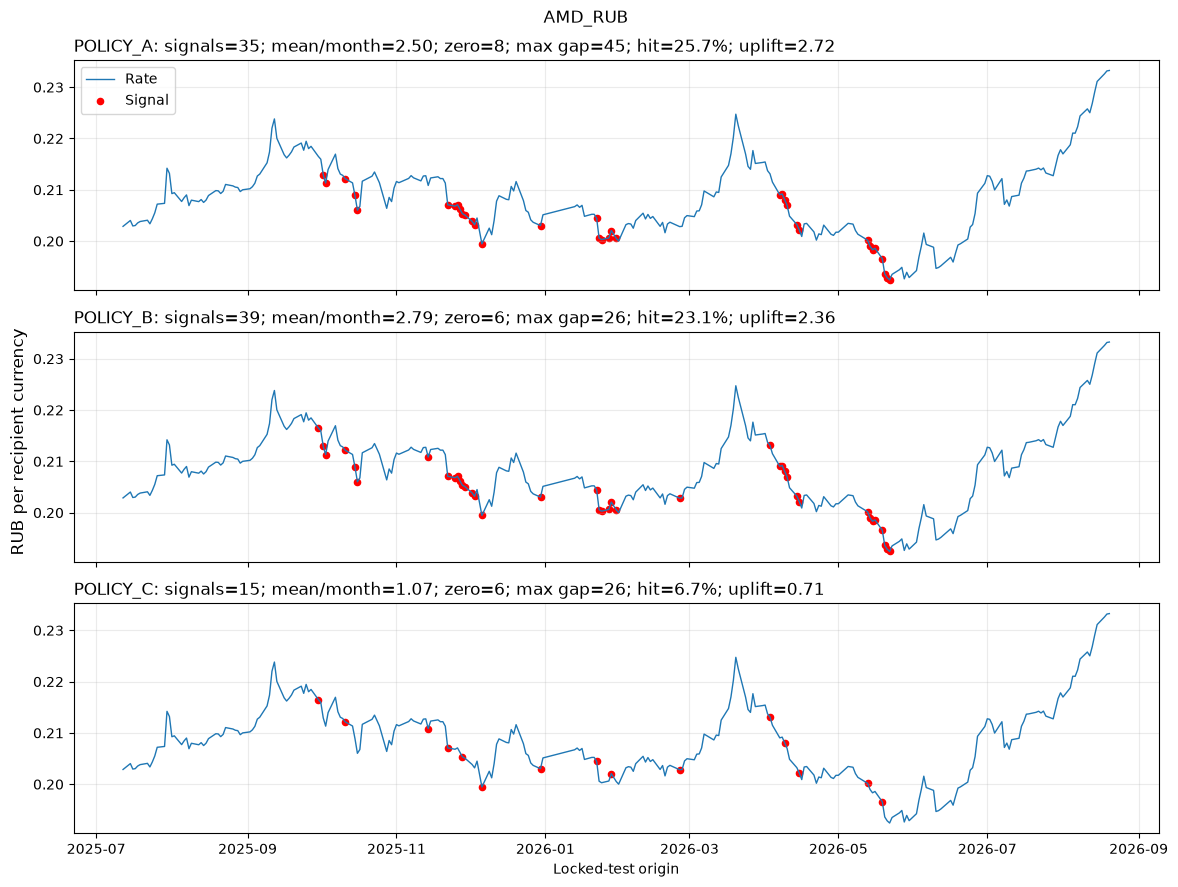

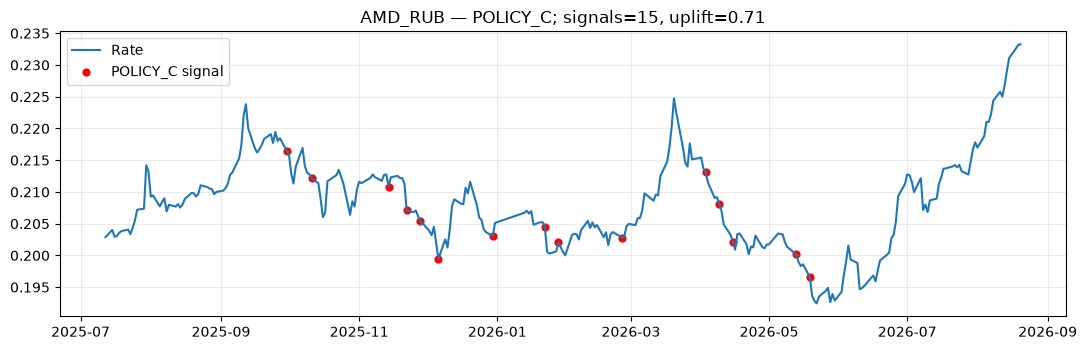

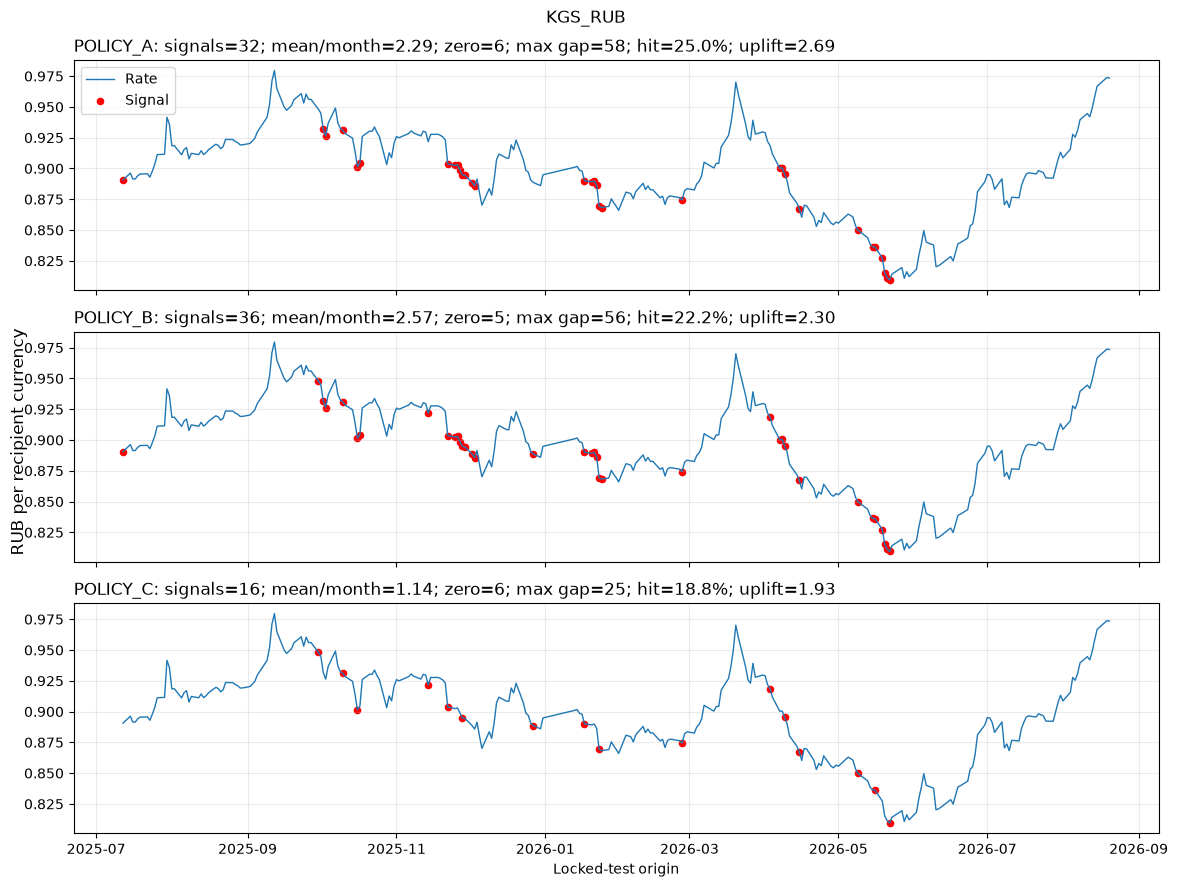

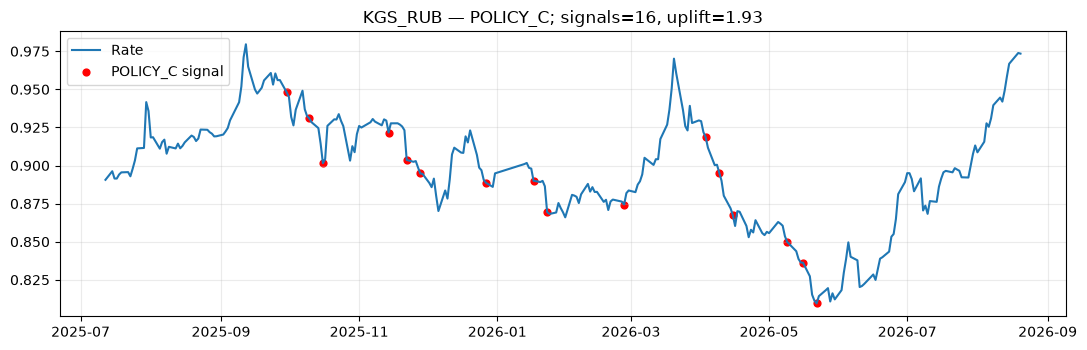

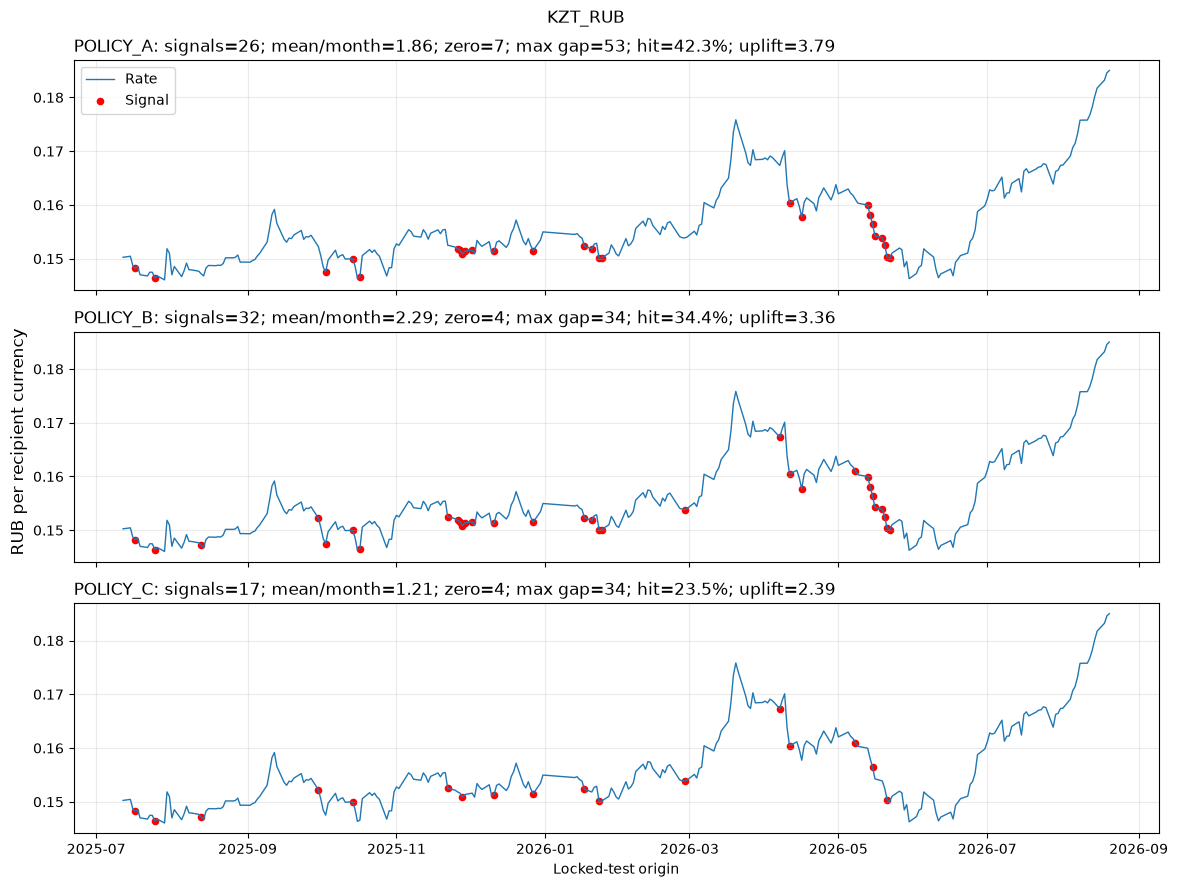

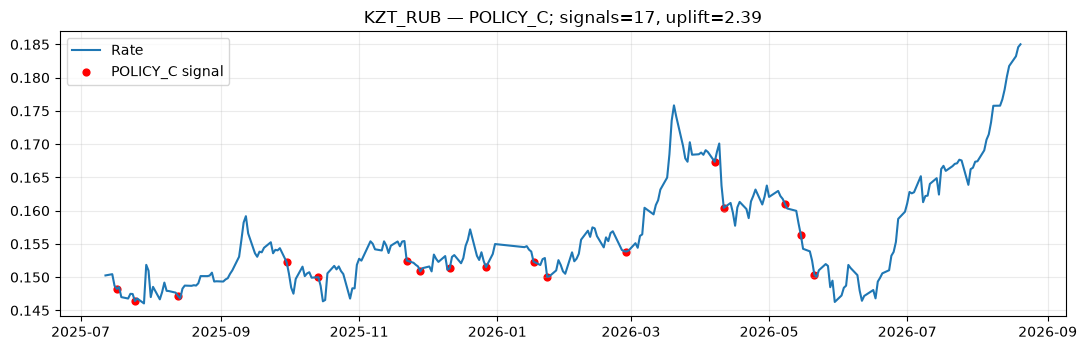

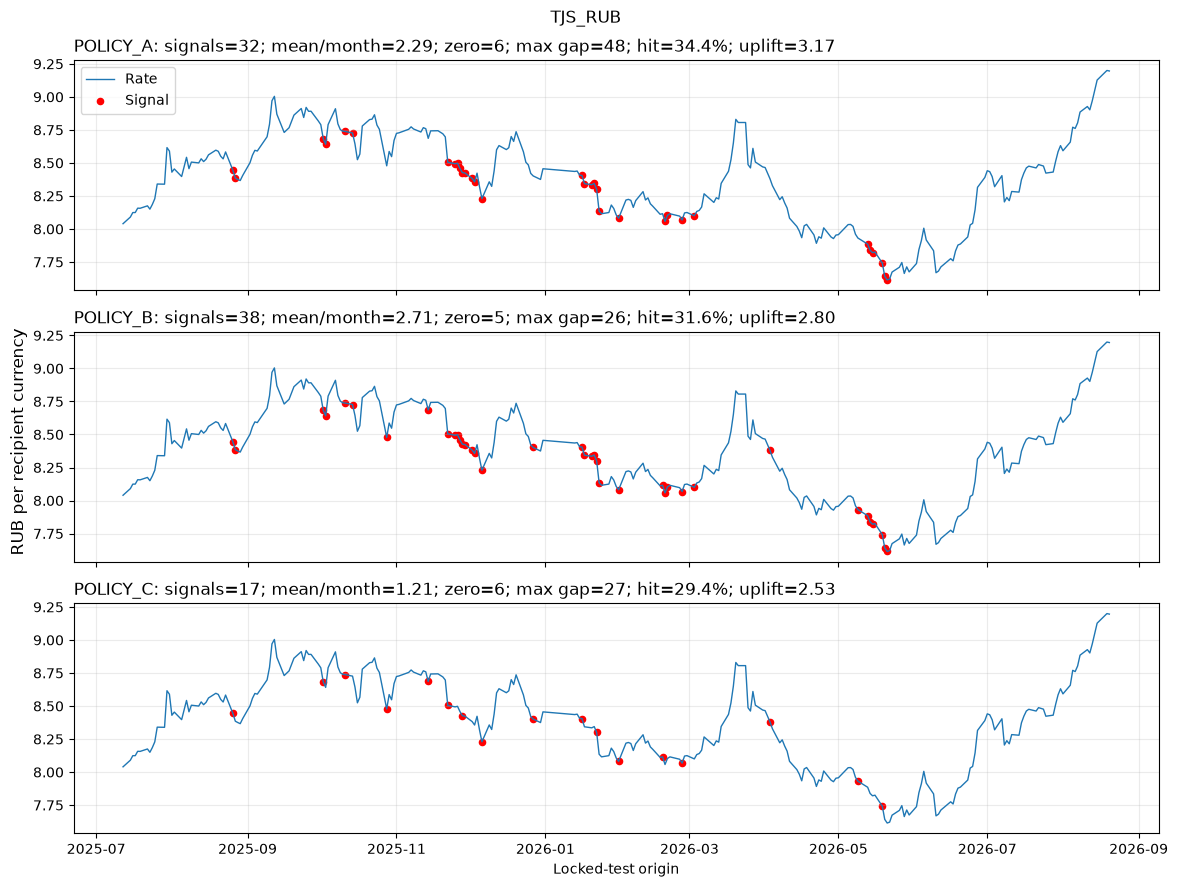

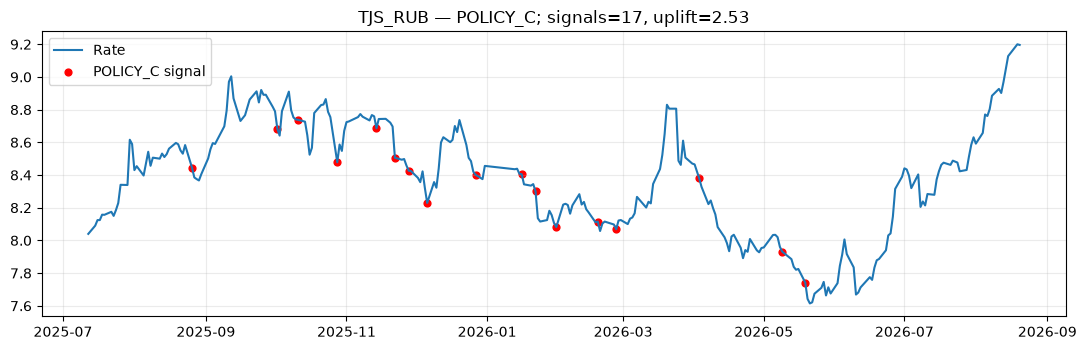

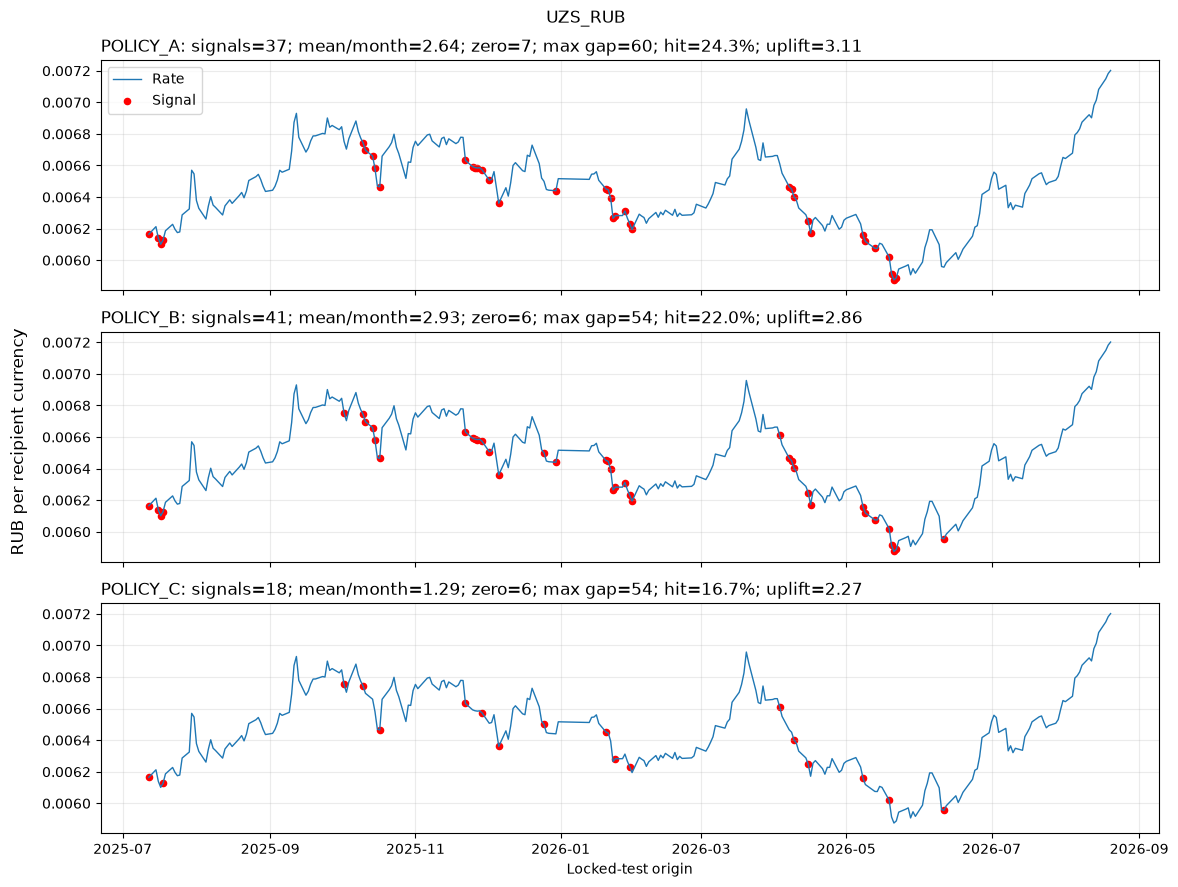

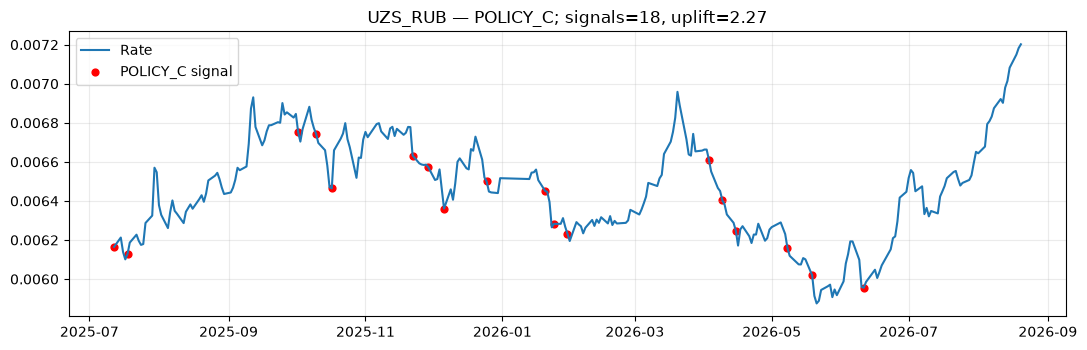

In [6]:
plot(run['test'],run['results'],ROOT/'reports/figures/adaptive_good_day_policy')

## 6. Leakage check

In [7]:
display(run['leakage'])
check='PASS' if run['leakage'].passed.all() else 'FAIL'
print('ADAPTIVE GOOD DAY POLICY LEAKAGE CHECK:',check)

,check,passed
0,rolling thresholds use past observations only,True
1,current T excluded,True
2,no actual future in signal generation,True
3,actual regret evaluation only,True
4,fallback state causal,True
5,cooldown causal,True
6,processing separated by corridor,True


ADAPTIVE GOOD DAY POLICY LEAKAGE CHECK: PASS


## 7. Final summary

Это диагностическое сравнение. Production policy автоматически не выбирается.

In [8]:
display(run['results'][['corridor','policy','n_signals','median_signals_per_month','months_with_zero_signals','max_gap_quote_observations','hit_rate','uplift']])
c=run['results'].loc[run['results'].policy.eq('POLICY_C')]
display(c[['corridor','months_with_zero_signals','share_months_with_2plus','uplift']])
print('No production winner selected.')
for name,path in run['paths'].items():print(f'{name}: {path.relative_to(ROOT)}')

,corridor,policy,n_signals,median_signals_per_month,months_with_zero_signals,max_gap_quote_observations,hit_rate,uplift
0,AMD_RUB,POLICY_A,35,0.0,8,45,0.257143,2.716298
1,AMD_RUB,POLICY_B,39,1.0,6,26,0.230769,2.362205
2,AMD_RUB,POLICY_C,15,1.0,6,26,0.066667,0.710900
3,KGS_RUB,POLICY_A,32,1.0,6,58,0.250000,2.690583
4,KGS_RUB,POLICY_B,36,1.0,5,56,0.222222,2.301055
5,KGS_RUB,POLICY_C,16,1.0,6,25,0.187500,1.931330
6,KZT_RUB,POLICY_A,26,1.0,7,53,0.423077,3.793103
7,KZT_RUB,POLICY_B,32,1.5,4,34,0.343750,3.357070
8,KZT_RUB,POLICY_C,17,1.0,4,34,0.235294,2.385686
9,TJS_RUB,POLICY_A,32,1.5,6,48,0.343750,3.173077


,corridor,months_with_zero_signals,share_months_with_2plus,uplift
2,AMD_RUB,6,0.357143,0.710900
5,KGS_RUB,6,0.357143,1.931330
8,KZT_RUB,4,0.428571,2.385686
11,TJS_RUB,6,0.428571,2.533784
14,UZS_RUB,6,0.500000,2.267003


No production winner selected.
results: reports\adaptive_good_day_policy_results.csv
predictions: reports\adaptive_good_day_policy_predictions.csv
monthly: reports\adaptive_good_day_policy_monthly.csv
report: reports\adaptive_good_day_policy_report.md
